## This task evaluates two execution algorithms, algo_1 and algo_2, using arrival slippage / IS slippage.
- Arrival slippage measures how the execution price compares to the market midpoint when the order first arrived. For a buy order, paying above the arrival mid is bad; for a sell order, selling below the arrival mid is bad.
- Lower slippage means better execution relative to the market mid-price when the order arrived. 

The goal is to compare raw performance and then assess performance after accounting for order difficulty.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("TCA_problem.csv")

# drop the extra index-like column if present
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print(df.shape)
df.head()

(40000, 7)


,IS_Slippage,ordersize,volatility,averageSpread,duration,notional,algo
0,118.374496,28.154509,150,2.638797,0.997847,1.981122e+08,algo_2
1,368.606221,193.324306,300,4.264819,1.000000,1.077540e+07,algo_2
2,356.180923,46.862604,300,1.954701,1.000000,2.647122e+07,algo_2
3,110.203046,49.780591,100,6.334067,0.941159,2.929402e+07,algo_1
4,-39.989627,7.890752,300,1.691854,1.000000,2.162974e+08,algo_2


In [22]:
print(df.info())
print('-----------------------------------------------------------------------------------------------------------------')

summary = df.groupby("algo").agg(
    n_orders=("IS_Slippage", "size"),
    mean_IS=("IS_Slippage", "mean"),
    median_IS=("IS_Slippage", "median"),
    std_IS=("IS_Slippage", "std"),
    mean_notional=("notional", "mean"),
    median_notional=("notional", "median"),
    mean_ordersize=("ordersize", "mean"),
    median_ordersize=("ordersize", "median"),
)
print(summary)

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   IS_Slippage    40000 non-null  float64
 1   ordersize      40000 non-null  float64
 2   volatility     40000 non-null  int64  
 3   averageSpread  40000 non-null  float64
 4   duration       40000 non-null  float64
 5   notional       40000 non-null  float64
 6   algo           40000 non-null  str    
dtypes: float64(5), int64(1), str(1)
memory usage: 2.1 MB
None
-----------------------------------------------------------------------------------------------------------------
        n_orders     mean_IS   median_IS      std_IS  mean_notional  \
algo                                                                  
algo_1     20000  203.833125  172.713069  185.341458   3.285703e+07   
algo_2     20000  243.925783  203.398346  207.477854   3.582345e+07   

        median_notional  mean_ordersize  medi

## 1. How would you compare the IS slippage of algo_1 and algo_2？Which one do you think performs better (smaller IS slippage)? Why?

- I first compare the two algos using average and median IS slippage.
- Since lower slippage is better, the algo with smaller mean/median appears better on a raw basis.
- I also examine the distribution because averages alone may be distorted by outliers or skew.

In [21]:
q1_stats = df.groupby("algo")["IS_Slippage"].agg(["count", "mean", "median", "std", "min", "max"])
print(q1_stats)

        count        mean      median         std         min          max
algo                                                                      
algo_1  20000  203.833125  172.713069  185.341458 -450.978358  1980.084979
algo_2  20000  243.925783  203.398346  207.477854 -423.340438  2433.721410


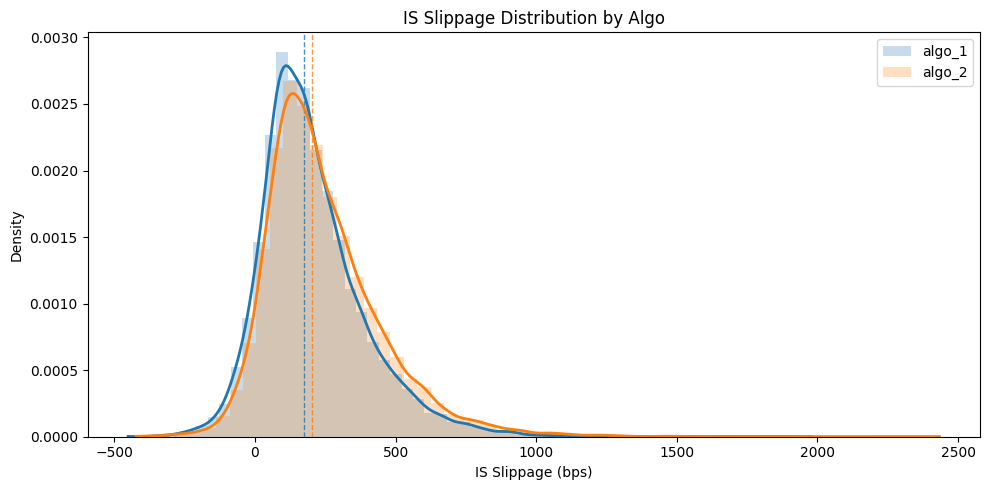

In [26]:
from scipy import stats

fig, ax = plt.subplots(figsize=(10, 5))

colors = plt.cm.tab10.colors  # up to 10 algos

for i, (algo_name, sub) in enumerate(df.groupby("algo")):
    data = sub["IS_Slippage"].dropna()
    color = colors[i % len(colors)]
    
    # Histogram (normalized to density so KDE is on same scale)
    ax.hist(data, bins=60, alpha=0.25, density=True, color=color, label=algo_name)
    
    # KDE overlay
    kde = stats.gaussian_kde(data)
    x = np.linspace(data.min(), data.max(), 300)
    ax.plot(x, kde(x), color=color, linewidth=2)
    
    # Optional: mark the median
    ax.axvline(data.median(), color=color, linestyle="--", linewidth=1, alpha=0.8)

ax.set_xlabel("IS Slippage (bps)")
ax.set_ylabel("Density")
ax.set_title("IS Slippage Distribution by Algo")
ax.legend()
plt.tight_layout()
plt.show()

On a raw unconditional basis, algo_1 appears to perform better, having lower average and median IS slippage while also centering around this lower IS with smaller variance. However, this comparison may not be fully fair if the two algos are assigned different types of orders.

## 2. Compute the notional weighted IS slippage of both algos. How would you interpret this number? What is its economic interpretation? How would you measure a single order's contribution to the notional weighted average?

## 3. Plot and describe the disitrbution of the 'features'. i.e. Volatility, Average Spread, Order Size and Duration.

## 4. What do you think is the relationship between the features and IS slippage? (You could start with monotonicity) Model IS slippage as a random variable whose parameters depend on the features. Explain how you determine your model.

## 5. Fit your model if possible. How would you interpret your fitting results? Which algo do you think is better? Why?

## 6. What if some orders are partially filled? (Hint: Construct an algo that may not fully fill but always beats arrival mid) How would you compare two algos when one algo requires fully fill while the other does not?

## 7. Describe how you would tackle this problem if you have access to more features. What features do you think might help?

I'm available for the internship starting June 1st to September 26th and can come to office 5 days/week. Thank you!